In [5]:
import os
import numpy as np
import gdown

# 1. Setup the Google Drive URL using your specific File ID
file_id = '1KiibVdV8l7XkBbq86CPwhMIxTkHWQP8t'
url = f'https://drive.google.com/uc?id={file_id}'
output_filename = 'dataset.npz'

# 2. Download the file from Google Drive into Kaggle
print("Downloading file from Google Drive...")
gdown.download(url, output_filename, quiet=False)

# 3. Load the .npz file using NumPy
if os.path.exists(output_filename):
    print("\nFile downloaded successfully! Loading data...")
    data = np.load(output_filename, allow_pickle=True)
    
    # 4. Show what arrays/keys are inside this file
    keys = data.files
    print("\n--- Success ---")
    print(f"Available keys inside your .npz file: {keys}")
    
    # Example of how to inspect the first key if it exists
    if len(keys) > 0:
        first_key = keys[0]
        print(f"\nInspecting arrays (Example: '{first_key}'):")
        print(f"Shape: {data[first_key].shape}")
else:
    print("\nDownload failed. Please check your Google Drive sharing permissions.")

Downloading...
From (original): https://drive.google.com/uc?id=1KiibVdV8l7XkBbq86CPwhMIxTkHWQP8t
From (redirected): https://drive.google.com/uc?id=1KiibVdV8l7XkBbq86CPwhMIxTkHWQP8t&confirm=t&uuid=41309f79-2ca2-4e6a-9854-03431f79ef29
To: /kaggle/working/dataset.npz
100%|██████████| 233M/233M [00:05<00:00, 40.4MB/s] 



File downloaded successfully! Loading data...

--- Success ---
Available keys inside your .npz file: ['X_train_normal', 'X_val_normal', 'X_test_normal', 'processed_abnormal_spectrograms', 'global_min', 'global_max', 'normal_files', 'abnormal_files']

Inspecting arrays (Example: 'X_train_normal'):
Shape: (606, 128, 320, 1)


In [6]:
# Extract everything from your loaded data object
X_train_normal = data['X_train_normal']
X_val_normal = data['X_val_normal']
X_test_normal = data['X_test_normal']
processed_abnormal_spectrograms = data['processed_abnormal_spectrograms']

print("Data shapes successfully extracted:")
print(f"Train Normal: {X_train_normal.shape}")
print(f"Val Normal:   {X_val_normal.shape}")
print(f"Test Normal:  {X_test_normal.shape}")
print(f"Abnormal:     {processed_abnormal_spectrograms.shape}")

Data shapes successfully extracted:
Train Normal: (606, 128, 320, 1)
Val Normal:   (202, 128, 320, 1)
Test Normal:  (203, 128, 320, 1)
Abnormal:     (407, 128, 320, 1)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 320, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 128, 320, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 160, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 160, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 80, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 80, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 40, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 16, 40, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_4 (UpSampling2D)  │ (None, 32, 80, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 80, 64)     │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_5 (UpSampling2D)  │ (None, 64, 160, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 64, 160, 32)    │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_6 (UpSampling2D)  │ (None, 128, 320, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 128, 320, 1)    │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 332,801 (1.27 MB)

 Trainable params: 332,801 (1.27 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50


2026-05-18 23:17:26.439846: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 23:17:26.609712: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 23:17:27.360220: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 23:17:27.532629: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


18/19 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - loss: 0.0230

2026-05-18 23:17:34.781825: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 23:17:35.088681: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 23:17:35.272632: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng4{k11=1} for conv %cudnn-conv-bw-input.7 = (f32[30,64,64,160]{3,2,1,0}, u8[0]{0}) custom-call(f32[30,32,64,160]{3,2,1,0} %bitcast.4443, f32[32,64,3,3]{3,2,1,0} %bitcast.3204), window={size=3x3 pad=1_1x1_1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convBackwardInput", metadata={op_type="Conv2DBackpropInput" op_name="gradient_tape/functional_2_1/conv2d_13_1/convolution/Conv2DBackpropInput" source_file="/u

19/19 ━━━━━━━━━━━━━━━━━━━━ 24s 908ms/step - loss: 0.0225 - val_loss: 0.0118
Epoch 2/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0080 - val_loss: 0.0028
Epoch 3/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0026 - val_loss: 0.0016
Epoch 4/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0016 - val_loss: 0.0014
Epoch 5/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 89ms/step - loss: 0.0014 - val_loss: 0.0013
Epoch 6/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0013 - val_loss: 0.0012
Epoch 7/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0012 - val_loss: 0.0012
Epoch 8/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0012 - val_loss: 0.0011
Epoch 9/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0012 - val_loss: 0.0013
Epoch 10/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step - loss: 0.0013 - val_loss: 0.0011
Epoch 11/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0011 - val_loss: 0.0011
Epoch 12/50
19/19 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 0.0011 - val

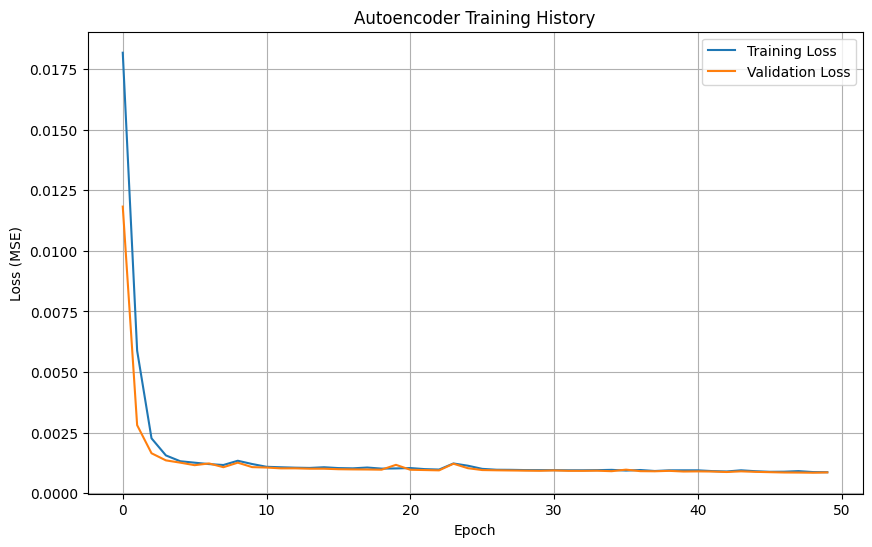

Autoencoder model weights saved to: /kaggle/working/autoencoder_weights.weights.h5


In [7]:
import os
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks

# Setup constants from your array shapes
INPUT_SHAPE = X_train_normal.shape[1:] # Generates (128, 320, 1) dynamically
BATCH_SIZE = 32
EPOCHS = 50

def build_autoencoder(input_shape):
    # Encoder
    encoder_input = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)

    # Decoder
    x = layers.Conv2D(128, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    autoencoder = models.Model(encoder_input, decoded)
    return autoencoder

# Build and compile
autoencoder = build_autoencoder(INPUT_SHAPE)
autoencoder.compile(optimizer='adam', loss='mse')
autoencoder.summary()

# Train the model
history = autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_val_normal, X_val_normal),
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)]
)

# Plot history
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Autoencoder Training History')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.grid(True)
plt.show()

# KAGGLE FIX: Save directly to the accessible working directory
MODEL_SAVE_PATH = '/kaggle/working/autoencoder_weights.weights.h5'
autoencoder.save_weights(MODEL_SAVE_PATH)
print(f"Autoencoder model weights saved to: {MODEL_SAVE_PATH}")

20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 87ms/step

Optimal Threshold (F1-score maximization): 0.000794

--- Evaluation Metrics with Optimal Threshold ---
AUC-ROC: 0.7757
F1 Score: 0.8562
Precision: 0.7600
Recall: 0.9803
Accuracy: 0.7803
Balanced Accuracy: 0.6798


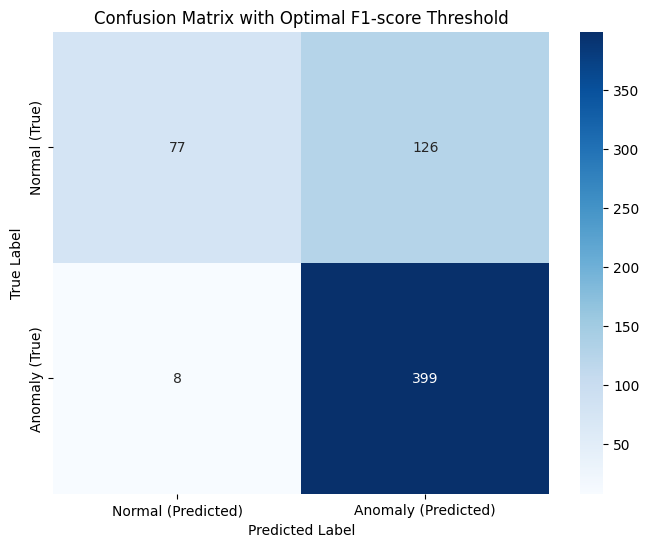

In [8]:
import numpy as np
import seaborn as sns
from sklearn.metrics import (f1_score, roc_auc_score, precision_score, 
                             recall_score, accuracy_score, confusion_matrix)

# 1. Combine test normal data and anomaly data for evaluation
X_eval = np.concatenate([X_test_normal, processed_abnormal_spectrograms], axis=0)

# Create true labels: 0 for Normal, 1 for Anomaly
true_labels = np.concatenate([
    np.zeros(len(X_test_normal)),
    np.ones(len(processed_abnormal_spectrograms))
])

# 2. Predict reconstructions
reconstructions = autoencoder.predict(X_eval)

# 3. Calculate MSE for every single sample
# Computes the average squared difference across the dimensions (128, 320, 1)
all_mse = np.mean(np.square(X_eval - reconstructions), axis=(1, 2, 3))

# 4. Find optimal threshold to maximize F1-score
thresholds = np.linspace(all_mse.min(), all_mse.max(), 1000)
optimal_f1 = -1
optimal_threshold = -1

for t in thresholds:
    predictions_optimized = (all_mse > t).astype(int)
    current_f1 = f1_score(true_labels, predictions_optimized)
    if current_f1 > optimal_f1:
        optimal_f1 = current_f1
        optimal_threshold = t

print(f"\nOptimal Threshold (F1-score maximization): {optimal_threshold:.6f}")

# Re-evaluate with optimal threshold
predictions_optimal = (all_mse > optimal_threshold).astype(int)

auc_roc_optimal = roc_auc_score(true_labels, all_mse)
f1_optimal = f1_score(true_labels, predictions_optimal)
precision_optimal = precision_score(true_labels, predictions_optimal)
recall_optimal = recall_score(true_labels, predictions_optimal)
accuracy_optimal = accuracy_score(true_labels, predictions_optimal)

print(f"\n--- Evaluation Metrics with Optimal Threshold ---")
print(f"AUC-ROC: {auc_roc_optimal:.4f}")
print(f"F1 Score: {f1_optimal:.4f}")
print(f"Precision: {precision_optimal:.4f}")
print(f"Recall: {recall_optimal:.4f}")
print(f"Accuracy: {accuracy_optimal:.4f}")

from sklearn.metrics import balanced_accuracy_score

# Calculate balanced accuracy using your optimal predictions
balanced_acc = balanced_accuracy_score(true_labels, predictions_optimal)

print(f"Balanced Accuracy: {balanced_acc:.4f}")

# Plot Confusion Matrix
cm_optimal = confusion_matrix(true_labels, predictions_optimal)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal (Predicted)', 'Anomaly (Predicted)'],
            yticklabels=['Normal (True)', 'Anomaly (True)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix with Optimal F1-score Threshold')
plt.show()

--- Class Distribution in Training Set ---
Normal (Class 0): 809
Anomaly (Class 1): 325
Calculated scale_pos_weight: 2.49

Training Balanced XGBoost Classifier...
XGBoost Training Complete!

--- Balanced XGBoost Evaluation Metrics ---
AUC-ROC:           0.9999
F1 Score:          0.9750
Precision:         1.0000
Recall (Sensitivity): 0.9512
Accuracy:          0.9859
Balanced Accuracy: 0.9756  <-- Pay close attention to this


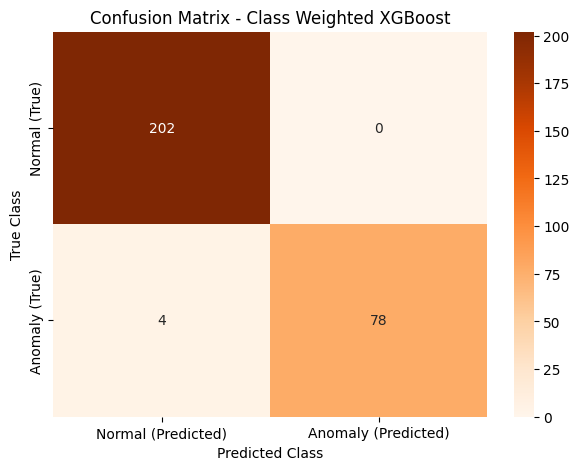

In [9]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (f1_score, roc_auc_score, precision_score, 
                             recall_score, accuracy_score, confusion_matrix,
                             balanced_accuracy_score)

# =====================================================================
# 1. PREPARE AND FLATTEN DATA FOR XGBOOST
# =====================================================================
all_normal = np.concatenate([data['X_train_normal'], data['X_val_normal'], data['X_test_normal']], axis=0)
abnormal = data['processed_abnormal_spectrograms']

X_normal_flat = all_normal.reshape(all_normal.shape[0], -1)
X_abnormal_flat = abnormal.reshape(abnormal.shape[0], -1)

X_combined = np.concatenate([X_normal_flat, X_abnormal_flat], axis=0)
y_combined = np.concatenate([
    np.zeros(X_normal_flat.shape[0]),
    np.ones(X_abnormal_flat.shape[0])
])

# =====================================================================
# 2. STRATIFIED TRAIN/TEST SPLIT
# =====================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y_combined, 
    test_size=0.2, 
    stratify=y_combined, # Crucial for imbalanced data to keep ratios identical
    random_state=42
)

# =====================================================================
# 3. DYNAMICALLY CALCULATE CLASS IMBALANCE WEIGHT
# =====================================================================
num_normals = np.sum(y_train == 0)
num_anomalies = np.sum(y_train == 1)
imbalance_ratio = num_normals / num_anomalies

print("--- Class Distribution in Training Set ---")
print(f"Normal (Class 0): {num_normals}")
print(f"Anomaly (Class 1): {num_anomalies}")
print(f"Calculated scale_pos_weight: {imbalance_ratio:.2f}\n")

# =====================================================================
# 4. INITIALIZE XGBOOST WITH BALANCE CONTROLS
# =====================================================================
print("Training Balanced XGBoost Classifier...")

xgb_model = XGBClassifier(
    n_estimators=150,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=imbalance_ratio, # Tells XGBoost to weight anomalies heavily
    eval_metric='logloss',
    tree_method='hist',
    random_state=42
)

xgb_model.fit(X_train, y_train)
print("XGBoost Training Complete!")

# =====================================================================
# 5. PREDICTIONS & EVALUATION
# =====================================================================
y_pred = xgb_model.predict(X_test)
y_prob = xgb_model.predict_proba(X_test)[:, 1]

auc_roc = roc_auc_score(y_test, y_prob)
f1 = f1_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
accuracy = accuracy_score(y_test, y_pred)
balanced_acc = balanced_accuracy_score(y_test, y_pred)

print(f"\n--- Balanced XGBoost Evaluation Metrics ---")
print(f"AUC-ROC:           {auc_roc:.4f}")
print(f"F1 Score:          {f1:.4f}")
print(f"Precision:         {precision:.4f}")
print(f"Recall (Sensitivity): {recall:.4f}")
print(f"Accuracy:          {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}  <-- Pay close attention to this")

# =====================================================================
# 6. PLOT CONFUSION MATRIX
# =====================================================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Normal (Predicted)', 'Anomaly (Predicted)'],
            yticklabels=['Normal (True)', 'Anomaly (True)'])
plt.xlabel('Predicted Class')
plt.ylabel('True Class')
plt.title('Confusion Matrix - Class Weighted XGBoost')
plt.show()

## Phase 2 (MiMII 2021)

In [5]:
import os
import glob

print("=== SOURCING YOUR UPLOADED KAGGLE DATA ===")

KAGGLE_INPUT_DIR = "../input"

if os.path.exists(KAGGLE_INPUT_DIR) and len(os.listdir(KAGGLE_INPUT_DIR)) > 0:
    print(f"Detected folders in Input: {os.listdir(KAGGLE_INPUT_DIR)}")
    
    # Dynamically find any .wav files in your uploaded dataset
    all_files = glob.glob(os.path.join(KAGGLE_INPUT_DIR, "**", "*.wav"), recursive=True)
    print(f"Total audio files found inside your upload: {len(all_files)}")
    
    # Find where source_test or source_train are hiding
    found_path = False
    for path, dirs, files in os.walk(KAGGLE_INPUT_DIR):
        if "source_test" in dirs or "source_train" in dirs:
            print(f"\n[SUCCESS] Copy this exact line for Step 2:\nDATA_DIR = '{path}'")
            found_path = True
            break
            
    if not found_path:
        print("\nDataset found, but we haven't detected 'source_test' or 'source_train' yet.")
        print("Let's see the deeper directory structure to find it:")
        for path, dirs, _ in os.walk(KAGGLE_INPUT_DIR):
            print(f"-> {path}")
else:
    print("Kaggle's input directory looks empty right now.")
    print("Quick check: Ensure your notebook session is fully started and look at the right-hand panel under 'Input' to make sure 'mimii-fan-data' is attached.")

=== SOURCING YOUR UPLOADED KAGGLE DATA ===
Detected folders in Input: ['datasets']
Total audio files found inside your upload: 4209

[SUCCESS] Copy this exact line for Step 2:
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'


In [7]:
import os
import glob
import numpy as np
import librosa

# 1. Your verified path
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'

# 2. Set Feature Parameters
N_MELS = 128
N_FFT = 1024       
HOP_LENGTH = 512   
N_FRAMES = 5       

def file_to_vector_array(file_name):
    """Loads a .wav file, computes Log-Mel Spectrogram, and blocks frames."""
    try:
        y, sr = librosa.load(file_name, sr=None)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max).T
        
        dims = N_MELS * N_FRAMES
        vector_array_size = len(log_mel) - N_FRAMES + 1
        
        if vector_array_size <= 0:
            return np.zeros((0, dims))
        
        vector_array = np.zeros((vector_array_size, dims))
        for t in range(N_FRAMES):
            vector_array[:, N_MELS * t : N_MELS * (t + 1)] = log_mel[t : vector_array_size + t]
            
        return vector_array
    except Exception as e:
        # If a specific file is corrupted, skip it instead of crashing
        return np.zeros((0, N_MELS * N_FRAMES))

# 3. Dynamically hunt for training files anywhere in the directory
print("=== STEP 2: DYNAMICALLY SEARCHING FOR TRAINING FILES ===")

# This searches recursively (** means look inside all subfolders)
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

# Filter out only the files that belong to training data
train_files = [f for f in all_wav_files if "train" in f.lower()]

print(f"Total .wav files found globally: {len(all_wav_files)}")
print(f"Total training files found: {len(train_files)}")

if len(train_files) == 0:
    print("\n[DEBUG] Could not find 'train' in any file paths. Let's see a sample of what we did find:")
    for f in all_wav_files[:5]:
        print(f"-> {f}")
    raise ValueError("No training files found. Check the printed sample paths above to see their layout!")

# Process the first 50 files as a quick safety test
print("\nProcessing a test batch of 50 training files...")
features_list = []
for f in train_files[:50]:
    vectors = file_to_vector_array(f)
    if vectors.shape[0] > 0:
        features_list.append(vectors)

# Merge list into a large matrix
x_test_batch = np.vstack(features_list)

print("\n=== EXTRACTION SUCCESSFUL ===")
print(f"Shape of extracted feature matrix for 50 files: {x_test_batch.shape}")
print(f"Each frame has {x_test_batch.shape[1]} features (128 mel bins x 5 frames).")

=== STEP 2: DYNAMICALLY SEARCHING FOR TRAINING FILES ===
Total .wav files found globally: 4209
Total training files found: 3009

Processing a test batch of 50 training files...

=== EXTRACTION SUCCESSFUL ===
Shape of extracted feature matrix for 50 files: (15450, 640)
Each frame has 640 features (128 mel bins x 5 frames).


## Phase 3 

In [10]:
import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, f1_score

# --- 1. CONFIGURATION ---
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'
N_MELS = 128
N_FFT = 1024       
HOP_LENGTH = 512   
N_FRAMES = 5       
BATCH_SIZE = 512   # DCASE baseline specification [cite: 130]
EPOCHS = 20        # Kept brief for efficient training on Kaggle
LEARNING_RATE = 0.001
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# --- 2. FEATURE EXTRACTION PIPELINE ---
def file_to_vector_array(file_name):
    """Processes a single 10-second wav file into a 640-dim frame matrix."""
    try:
        y, sr = librosa.load(file_name, sr=None)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS
        )
        log_mel = librosa.power_to_db(mel_spec, ref=np.max).T
        
        dims = N_MELS * N_FRAMES
        vector_array_size = len(log_mel) - N_FRAMES + 1
        if vector_array_size <= 0:
            return np.zeros((0, dims))
        
        vector_array = np.zeros((vector_array_size, dims))
        for t in range(N_FRAMES):
            vector_array[:, N_MELS * t : N_MELS * (t + 1)] = log_mel[t : vector_array_size + t]
        return vector_array
    except Exception:
        return np.zeros((0, N_MELS * N_FRAMES))

def extract_dataset_features(file_list, description="Dataset"):
    """Loops over a list of files and stacks their vectors together."""
    print(f"Extracting features for {len(file_list)} files ({description})...")
    features_list = []
    for f in file_list:
        vectors = file_to_vector_array(f)
        if vectors.shape[0] > 0:
            features_list.append(vectors)
    return np.vstack(features_list)

# --- 3. DYNAMIC DATA LOADING & SPLITTING ---
print("\n=== STEP 3.1: GATHERING AND SORTING ALL AUDIO PATHS ===")
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

# Separate into Train, Source Test, and Target Test lists based on paths and names
train_files = [f for f in all_wav_files if "train" in f.lower()]
test_files = [f for f in all_wav_files if "test" in f.lower()]

source_test_normal = [f for f in test_files if "source" in f.lower() and "normal" in f.lower()]
source_test_anomaly = [f for f in test_files if "source" in f.lower() and "anomaly" in f.lower()]

target_test_normal = [f for f in test_files if "target" in f.lower() and "normal" in f.lower()]
target_test_anomaly = [f for f in test_files if "target" in f.lower() and "anomaly" in f.lower()]

print(f"-> Total Training Files: {len(train_files)}")
print(f"-> Source Test: {len(source_test_normal)} Normal, {len(source_test_anomaly)} Anomaly")
print(f"-> Target Test: {len(target_test_normal)} Normal, {len(target_test_anomaly)} Anomaly")

print("\nProcessing full training dataset features...")
x_train = extract_dataset_features(train_files, "Training Data")
input_dim = N_MELS * N_FRAMES # 640

# Build Data Loader
train_tensor = torch.tensor(x_train, dtype=torch.float32)
train_loader = DataLoader(TensorDataset(train_tensor), batch_size=BATCH_SIZE, shuffle=True)

# --- 4. AUTOENCODER MODEL LAYERS ---
class DCASE2021Autoencoder(nn.Module):
    def __init__(self, input_dim=640):
        super(DCASE2021Autoencoder, self).__init__()
        # 640 -> 128 -> 128 -> 128 -> 128 -> 8 Bottleneck
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, 128), 
            nn.BatchNorm1d(128), 
            nn.ReLU(),
            nn.Linear(128, input_dim)
        )

    def forward(self, x):
        return self.decoder(self.encoder(x))

model = DCASE2021Autoencoder(input_dim=input_dim).to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# --- 5. TRAINING PROGRESS LOOP ---
print("\n=== STEP 3.2: TRAINING THE NETWORK ===")
model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for batch in train_loader:
        inputs = batch[0].to(DEVICE)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, inputs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
        
    print(f"Epoch [{epoch+1}/{EPOCHS}], Loss: {total_loss / len(train_loader.dataset):.4f}")

# --- 6. FILE-LEVEL EVALUATION ENGINE ---
def evaluate_domain(normal_files, anomaly_files, label="Domain"):
    """Calculates the mean reconstruction error per individual file to find AUC."""
    model.eval()
    y_true = []
    y_scores = []
    
    def process_group(files, actual_class):
        for f in files:
            vectors = file_to_vector_array(f)
            if vectors.shape[0] == 0:
                continue
            inputs = torch.tensor(vectors, dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                outputs = model(inputs)
                # Average MSE across all dimensions per frame, then average across the whole file [cite: 131]
                file_score = torch.mean(torch.mean((outputs - inputs) ** 2, dim=1)).item()
            y_scores.append(file_score)
            y_true.append(actual_class)
            
    # Process regular files (0) vs malfunction files (1)
    process_group(normal_files, 0)
    normal_scores_only = list(y_scores) # Save just the normal ones to calculate threshold
    process_group(anomaly_files, 1)
    
    auc = roc_auc_score(y_true, y_scores)
    
    # Check F1-Score using standard 90th percentile threshold of healthy files
    threshold = np.percentile(normal_scores_only, 90)
    y_pred = [1 if s > threshold else 0 for s in y_scores]
    f1 = f1_score(y_true, y_pred)
    
    print(f"\n>> {label} RESULTS:")
    print(f"   AUC-ROC Score: {auc:.4f}")
    print(f"   F1-Score:      {f1:.4f}")
    return auc

# --- 7. EVALUATE BOTH SIDES AND CALCULATE DOMAIN SHIFT DROP ---
print("\n=== STEP 3.3: RUNNING SIDE-BY-SIDE EVALUATIONS ===")
print("Running Source Test Evaluation...")
source_auc = evaluate_domain(source_test_normal, source_test_anomaly, "SOURCE TEST (Original Environment)")

print("\nRunning Target Test Evaluation...")
target_auc = evaluate_domain(target_test_normal, target_test_anomaly, "TARGET TEST (Shifted Environment)")

print("\n=== STAGE 2 FINAL OUTCOME ===")
print(f"Source Domain Validation AUC: {source_auc:.4f}")
print(f"Target Domain Validation AUC: {target_auc:.4f}")
print(f"Performance drop due to environmental Domain Shift: {max(0, source_auc - target_auc):.4f}")

# Save state dict for fine-tuning in Stage 3
torch.save(model.state_dict(), "stage2_trained_baseline.pth")
print("\nModel checkpoint securely saved as 'stage2_trained_baseline.pth'. Pipeline execution complete.")

Using device: cuda

=== STEP 3.1: GATHERING AND SORTING ALL AUDIO PATHS ===
-> Total Training Files: 3009
-> Source Test: 300 Normal, 300 Anomaly
-> Target Test: 300 Normal, 300 Anomaly

Processing full training dataset features...
Extracting features for 3009 files (Training Data)...

=== STEP 3.2: TRAINING THE NETWORK ===
Epoch [1/20], Loss: 73.7389
Epoch [2/20], Loss: 11.0674
Epoch [3/20], Loss: 10.0922
Epoch [4/20], Loss: 9.6974
Epoch [5/20], Loss: 9.5355
Epoch [6/20], Loss: 9.4405
Epoch [7/20], Loss: 9.3846
Epoch [8/20], Loss: 9.3376
Epoch [9/20], Loss: 9.3043
Epoch [10/20], Loss: 9.2751
Epoch [11/20], Loss: 9.2483
Epoch [12/20], Loss: 9.2268
Epoch [13/20], Loss: 9.2092
Epoch [14/20], Loss: 9.1952
Epoch [15/20], Loss: 9.1798
Epoch [16/20], Loss: 9.1654
Epoch [17/20], Loss: 9.1542
Epoch [18/20], Loss: 9.1443
Epoch [19/20], Loss: 9.1355
Epoch [20/20], Loss: 9.1267

=== STEP 3.3: RUNNING SIDE-BY-SIDE EVALUATIONS ===
Running Source Test Evaluation...

>> SOURCE TEST (Original Environm

In [3]:
import os
import glob
import numpy as np
import librosa
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import roc_auc_score, f1_score

# --- 1. CONFIGURATION ---
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'
N_MELS = 128
N_FFT = 1024       
HOP_LENGTH = 512   
N_FRAMES = 5       
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {DEVICE}")

# --- 2. FEATURE EXTRACTION UTILITIES ---
def file_to_vector_array(file_name):
    try:
        y, sr = librosa.load(file_name, sr=None)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=N_FFT, hop_length=HOP_LENGTH, n_mels=N_MELS)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max).T
        dims = N_MELS * N_FRAMES
        vector_array_size = len(log_mel) - N_FRAMES + 1
        if vector_array_size <= 0: return np.zeros((0, dims))
        vector_array = np.zeros((vector_array_size, dims))
        for t in range(N_FRAMES):
            vector_array[:, N_MELS * t : N_MELS * (t + 1)] = log_mel[t : vector_array_size + t]
        return vector_array
    except Exception:
        return np.zeros((0, N_MELS * N_FRAMES))

def extract_dataset_features(file_list, desc="Dataset"):
    print(f"Extracting features for {len(file_list)} files ({desc})...")
    features_list = []
    for f in file_list:
        vectors = file_to_vector_array(f)
        if vectors.shape[0] > 0: features_list.append(vectors)
    return np.vstack(features_list)

# --- 3. DATA HARVESTING ---
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)
train_files = [f for f in all_wav_files if "train" in f.lower() and "source" in f.lower()]
target_train_files = [f for f in all_wav_files if "train" in f.lower() and "target" in f.lower() and "anomaly" not in os.path.basename(f).lower()]

test_files = [f for f in all_wav_files if "test" in f.lower()]
source_test_normal = [f for f in test_files if "source" in f.lower() and "normal" in f.lower()]
source_test_anomaly = [f for f in test_files if "source" in f.lower() and "anomaly" in f.lower()]
target_test_normal = [f for f in test_files if "target" in f.lower() and "normal" in f.lower()]
target_test_anomaly = [f for f in test_files if "target" in f.lower() and "anomaly" in f.lower()]

print(f"Loaded: {len(train_files)} Source Train | {len(target_train_files)} Target Train Adaptation Files")

# --- 4. AUTOENCODER MODEL STRUCTURE ---
class DCASE2021Autoencoder(nn.Module):
    def __init__(self, input_dim=640):
        super(DCASE2021Autoencoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 8)
        )
        self.decoder = nn.Sequential(
            nn.Linear(8, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, 128), nn.BatchNorm1d(128), nn.ReLU(),
            nn.Linear(128, input_dim)
        )
    def forward(self, x): return self.decoder(self.encoder(x))

# --- 5. STAGE 2: BASELINE TRAINING ---
print("\n=== STARTING STAGE 2: TRAINING BASELINE MODEL ===")
x_train = extract_dataset_features(train_files, "Source Train")
train_loader = DataLoader(TensorDataset(torch.tensor(x_train, dtype=torch.float32)), batch_size=512, shuffle=True)

model = DCASE2021Autoencoder().to(DEVICE)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

model.train()
for epoch in range(15):
    total_loss = 0
    for batch in train_loader:
        inputs = batch[0].to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(inputs), inputs)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * inputs.size(0)
    print(f"Epoch [{epoch+1}/15], Baseline Loss: {total_loss / len(train_loader.dataset):.4f}")

def evaluate_network(label=""):
    model.eval()
    y_true, y_scores = [], []
    def process(files, cl):
        for f in files:
            v = file_to_vector_array(f)
            if v.shape[0] == 0: continue
            ins = torch.tensor(v, dtype=torch.float32).to(DEVICE)
            with torch.no_grad():
                scores = torch.mean(torch.mean((model(ins) - ins) ** 2, dim=1)).item()
            y_scores.append(scores)
            y_true.append(cl)
    process(source_test_normal if "SOURCE" in label else target_test_normal, 0)
    process(source_test_anomaly if "SOURCE" in label else target_test_anomaly, 1)
    return roc_auc_score(y_true, y_scores)

print("\n--- PRE-ADAPTATION BASELINE EVALUATION ---")
base_source_auc = evaluate_network("SOURCE")
base_target_auc = evaluate_network("TARGET")
print(f"Baseline Source AUC: {base_source_auc:.4f} | Baseline Target AUC: {base_target_auc:.4f}")

# --- 6. STAGE 3: DOMAIN ADAPTATION ---
print("\n=== STARTING STAGE 3: DOMAIN FINE-TUNING ===")
x_target = extract_dataset_features(target_train_files, "Target Adapt")
target_loader = DataLoader(TensorDataset(torch.tensor(x_target, dtype=torch.float32)), batch_size=32, shuffle=True)

# Freeze the first 3 layers of encoder
frozen_blocks = list(model.encoder.children())[:9]
for layer in frozen_blocks:
    for param in layer.parameters(): param.requires_grad = False

adapt_optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=0.0001)

for epoch in range(10):
    model.train()
    for layer in frozen_blocks: layer.eval() # Protect BatchNorm statistics
    total_loss = 0
    for batch in target_loader:
        inputs = batch[0].to(DEVICE)
        adapt_optimizer.zero_grad()
        loss = criterion(model(inputs), inputs)
        loss.backward()
        adapt_optimizer.step()
        total_loss += loss.item() * inputs.size(0)
    print(f"Adaptation Epoch [{epoch+1}/10], Target Loss: {total_loss / len(target_loader.dataset):.4f}")

# --- 7. FINAL METRICS EVALUATION ---
print("\n=== FINAL POST-ADAPTATION RECOVERY METRICS ===")
post_source_auc = evaluate_network("SOURCE")
post_target_auc = evaluate_network("TARGET")

print(f"\n>> Source Domain AUC (Before: {base_source_auc:.4f}) -> After Adaptation: {post_source_auc:.4f}")
print(f">> Target Domain AUC (Before: {base_target_auc:.4f}) -> After Adaptation: {post_target_auc:.4f}")
print(f">> Net Performance Recovery Gain: {max(0, post_target_auc - base_target_auc):.4f}")

Using device: cuda
Loaded: 3000 Source Train | 9 Target Train Adaptation Files

=== STARTING STAGE 2: TRAINING BASELINE MODEL ===
Extracting features for 3000 files (Source Train)...
Epoch [1/15], Baseline Loss: 74.3918
Epoch [2/15], Baseline Loss: 11.2827
Epoch [3/15], Baseline Loss: 10.1449
Epoch [4/15], Baseline Loss: 9.7408
Epoch [5/15], Baseline Loss: 9.5498
Epoch [6/15], Baseline Loss: 9.4506
Epoch [7/15], Baseline Loss: 9.3853
Epoch [8/15], Baseline Loss: 9.3370
Epoch [9/15], Baseline Loss: 9.3021
Epoch [10/15], Baseline Loss: 9.2738
Epoch [11/15], Baseline Loss: 9.2497
Epoch [12/15], Baseline Loss: 9.2288
Epoch [13/15], Baseline Loss: 9.2106
Epoch [14/15], Baseline Loss: 9.1969
Epoch [15/15], Baseline Loss: 9.1826

--- PRE-ADAPTATION BASELINE EVALUATION ---
Baseline Source AUC: 0.6230 | Baseline Target AUC: 0.5637

=== STARTING STAGE 3: DOMAIN FINE-TUNING ===
Extracting features for 9 files (Target Adapt)...
Adaptation Epoch [1/10], Target Loss: 16.0097
Adaptation Epoch [2/10],

In [11]:
import os
import glob
import numpy as np
import librosa

# Your verified Kaggle path
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'

# Target dimensions matching your first model exactly
TARGET_MELS = 128
TARGET_TIME_STEPS = 320  # Your input shape length requirement

def file_to_2d_spectrogram(file_name):
    """
    Loads a wav file and resizes its log-mel spectrogram 
    to match your exact 2D CNN input shape specifications.
    """
    try:
        y, sr = librosa.load(file_name, sr=None)
        
        # Calculate hop length dynamically to always get exactly 320 time frames
        # 10 seconds of audio at 16kHz is 160,000 samples. 160000 / 320 = 500
        hop_length = int(len(y) / TARGET_TIME_STEPS)
        
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=hop_length, n_mels=TARGET_MELS
        )
        
        # Trim or pad the time axis slightly if it's off by 1-2 frames due to rounding
        mel_spec = mel_spec[:, :TARGET_TIME_STEPS]
        
        # Convert to log scale (dB) and normalize between 0 and 1 (matching Sigmoid decoder constraints)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-6)
        
        # Add the channel dimension to make it (128, 320, 1)
        return np.expand_dims(log_mel, axis=-1)
    except Exception as e:
        return None

# Quick dynamic check
print("=== TESTING 2D CNN FEATURE EXTRACTION LAYOUT ===")
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)
train_files = [f for f in all_wav_files if "train" in f.lower()]

print(f"Discovered {len(train_files)} training files.")
print("Testing extraction on the first 5 files...")

sample_features = []
for f in train_files[:5]:
    spec = file_to_2d_spectrogram(f)
    if spec is not None:
        sample_features.append(spec)

sample_matrix = np.array(sample_features)
print(f"\n-> Success! Extracted batch shape: {sample_matrix.shape}")
print(f"-> Individual image dimensions: {sample_matrix.shape[1:]} (Height, Width, Channels)")

=== TESTING 2D CNN FEATURE EXTRACTION LAYOUT ===
Discovered 3009 training files.
Testing extraction on the first 5 files...

-> Success! Extracted batch shape: (5, 128, 320, 1)
-> Individual image dimensions: (128, 320, 1) (Height, Width, Channels)


In [12]:
import os
import glob
import numpy as np
import librosa
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import (f1_score, roc_auc_score, precision_score, 
                             recall_score, accuracy_score, confusion_matrix,
                             balanced_accuracy_score)

# =====================================================================
# 1. CONFIGURATION & TARGET SHAPES
# =====================================================================
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'

TARGET_MELS = 128
TARGET_TIME_STEPS = 320
BATCH_SIZE = 32
EPOCHS = 30  # Adjusted for quick execution on cloud GPU

# =====================================================================
# 2. AUDIO PROCESSING PIPELINE (RAW TO 2D SPECTROGRAM)
# =====================================================================
def file_to_2d_spectrogram(file_name):
    """
    Loads a .wav file and scales its log-mel spectrogram 
    to match your exact 2D CNN (128, 320, 1) input matrix.
    """
    try:
        y, sr = librosa.load(file_name, sr=None)
        
        # Force exact 320 time steps based on sample size
        hop_length = int(len(y) / TARGET_TIME_STEPS)
        
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=hop_length, n_mels=TARGET_MELS
        )
        
        # Force fix rounding variations
        mel_spec = mel_spec[:, :TARGET_TIME_STEPS]
        
        # Convert to log decibel scale
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Min-Max Normalization to scale values tightly between [0, 1] for Sigmoid decoder activation
        log_mel = (log_mel - log_mel.min()) / (log_mel.max() - log_mel.min() + 1e-6)
        
        return np.expand_dims(log_mel, axis=-1)
    except Exception:
        return None

def batch_extract_features(file_list, description="Dataset"):
    print(f"Extracting 2D spectrograms for {len(file_list)} files ({description})...")
    features = []
    for f in file_list:
        spec = file_to_2d_spectrogram(f)
        if spec is not None:
            features.append(spec)
    return np.array(features)

# =====================================================================
# 3. DATA HARVESTING & DOMAIN EXTRACTION
# =====================================================================
print("=== GATHERING AND SORTING ALL AUDIO PATHS ===")
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

# Parse filenames cleanly matching your data tree layout
train_files = [f for f in all_wav_files if "train" in f.lower()]
test_files = [f for f in all_wav_files if "test" in f.lower()]

source_test_normal = [f for f in test_files if "source" in f.lower() and "normal" in f.lower()]
source_test_anomaly = [f for f in test_files if "source" in f.lower() and "anomaly" in f.lower()]

target_test_normal = [f for f in test_files if "target" in f.lower() and "normal" in f.lower()]
target_test_anomaly = [f for f in test_files if "target" in f.lower() and "anomaly" in f.lower()]

print(f"-> Found Training Files: {len(train_files)}")
print(f"-> Source Test Partition: {len(source_test_normal)} Normal, {len(source_test_anomaly)} Anomaly")
print(f"-> Target Test Partition: {len(target_test_normal)} Normal, {len(target_test_anomaly)} Anomaly")

# Convert full file lists into arrays
print("\nLoading Training Array...")
X_train_normal = batch_extract_features(train_files, "Training Data")

print("\nLoading Testing Evaluation Streams...")
X_test_source_normal = batch_extract_features(source_test_normal, "Source Test Normal")
X_test_source_anomaly = batch_extract_features(source_test_anomaly, "Source Test Anomaly")

X_test_target_normal = batch_extract_features(target_test_normal, "Target Test Normal")
X_test_target_anomaly = batch_extract_features(target_test_anomaly, "Target Test Anomaly")

INPUT_SHAPE = X_train_normal.shape[1:] # (128, 320, 1)

# =====================================================================
# 4. YOUR EXACT OPTIMIZED CNN AUTOENCODER ARCHITECTURE
# =====================================================================
def build_optimized_autoencoder(input_shape):
    # --- ENCODER ---
    encoder_input = layers.Input(shape=input_shape)
    
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same')(encoder_input)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    
    # Block 3: Tightened Bottleneck Layer
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    encoded = layers.LeakyReLU(negative_slope=0.1)(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(encoded)

    # --- DECODER ---
    x = layers.Conv2D(32, (3, 3), padding='same')(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.UpSampling2D((2, 2))(x)
    
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

    return models.Model(encoder_input, decoded)

autoencoder = build_optimized_autoencoder(INPUT_SHAPE)
autoencoder.compile(optimizer='adam', loss='mse')

# =====================================================================
# 5. TRAINING CONTROL PIPELINE
# =====================================================================
print("\nStarting CNN Model Training on Cloud Infrastructure...")
history = autoencoder.fit(
    X_train_normal, X_train_normal, 
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(X_test_source_normal, X_test_source_normal), # Using source test normals as a validation gauge
    callbacks=[callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)]
)

# Save weights to current Kaggle output directory
MODEL_SAVE_PATH = '/kaggle/working/optimized_cnn_stage2_weights.weights.h5'
autoencoder.save_weights(MODEL_SAVE_PATH)
print(f"\nWeights securely cached to: {MODEL_SAVE_PATH}")

# =====================================================================
# 6. DOUBLE-DOMAIN EVALUATION ENGINE
# =====================================================================
def evaluate_tf_domain(normal_features, anomaly_features, domain_label=""):
    """Runs predictions over the evaluation block and optimizes metrics threshold."""
    # Stack features to match test design logic
    X_eval = np.concatenate([normal_features, anomaly_features], axis=0)
    true_labels = np.concatenate([np.zeros(len(normal_features)), np.ones(len(anomaly_features))])
    
    # Compute reconstruction loss
    reconstructions = autoencoder.predict(X_eval)
    all_mse = np.mean(np.square(X_eval - reconstructions), axis=(1, 2, 3))
    
    # Locate maximum boundary threshold across operational space limits
    thresholds = np.linspace(all_mse.min(), all_mse.max(), 1000)
    optimal_f1 = -1
    optimal_threshold = -1

    for t in thresholds:
        predictions_temp = (all_mse > t).astype(int)
        current_f1 = f1_score(true_labels, predictions_temp, zero_division=0)
        if current_f1 > optimal_f1:
            optimal_f1 = current_f1
            optimal_threshold = t

    # Compile validation data metrics matrix mapping
    predictions_optimal = (all_mse > optimal_threshold).astype(int)
    auc_roc_optimal = roc_auc_score(true_labels, all_mse)
    
    print(f"\n--- {domain_label} PERFORMANCE METRICS ---")
    print(f"Optimal Threshold:  {optimal_threshold:.6f}")
    print(f"AUC-ROC Score:      {auc_roc_optimal:.4f}")
    print(f"Optimized F1 Score: {f1_score(true_labels, predictions_optimal, zero_division=0):.4f}")
    print(f"Precision Score:    {precision_score(true_labels, predictions_optimal, zero_division=0):.4f}")
    print(f"Recall Score:       {recall_score(true_labels, predictions_optimal, zero_division=0):.4f}")
    
    return auc_roc_optimal

# Run side-by-side verification evaluation metrics mapping
print("\n=== STAGE 2 MULTI-DOMAIN COMPILATION ===")
print("Processing Source Domain Metrics...")
source_cnn_auc = evaluate_tf_domain(X_test_source_normal, X_test_source_anomaly, "SOURCE DOMAIN")

print("\nProcessing Target Domain Metrics...")
target_cnn_auc = evaluate_tf_domain(X_test_target_normal, X_test_target_anomaly, "TARGET DOMAIN")

print("\n=== FINAL STAGE 2 OUTCOME ===")
print(f"Source CNN Model AUC: {source_cnn_auc:.4f}")
print(f"Target CNN Model AUC: {target_cnn_auc:.4f}")
print(f"CNN Model Performance Drop via Domain Shift: {max(0, source_cnn_auc - target_cnn_auc):.4f}")

2026-05-18 19:41:04.612285: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779133264.891786      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779133264.971092      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779133265.635515      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779133265.635558      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779133265.635561      57 computation_placer.cc:177] computation placer alr

=== GATHERING AND SORTING ALL AUDIO PATHS ===
-> Found Training Files: 3009
-> Source Test Partition: 300 Normal, 300 Anomaly
-> Target Test Partition: 300 Normal, 300 Anomaly

Loading Training Array...
Extracting 2D spectrograms for 3009 files (Training Data)...

Loading Testing Evaluation Streams...
Extracting 2D spectrograms for 300 files (Source Test Normal)...
Extracting 2D spectrograms for 300 files (Source Test Anomaly)...
Extracting 2D spectrograms for 300 files (Target Test Normal)...
Extracting 2D spectrograms for 300 files (Target Test Anomaly)...


I0000 00:00:1779133343.035741      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13671 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779133343.041085      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Starting CNN Model Training on Cloud Infrastructure...
Epoch 1/30


I0000 00:00:1779133351.835450     260 service.cc:152] XLA service 0x782dac04fc70 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779133351.835512     260 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779133351.835520     260 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779133352.693275     260 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-18 19:42:37.285957: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 19:42:37.609087: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 19:42:38.648021: E external/local_xl

 1/95 ━━━━━━━━━━━━━━━━━━━━ 28:45 18s/step - loss: 0.0740

I0000 00:00:1779133365.503787     260 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


95/95 ━━━━━━━━━━━━━━━━━━━━ 33s 154ms/step - loss: 0.0133 - val_loss: 0.0270
Epoch 2/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 81ms/step - loss: 0.0049 - val_loss: 0.0254
Epoch 3/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0045 - val_loss: 0.0214
Epoch 4/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0042 - val_loss: 0.0161
Epoch 5/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 85ms/step - loss: 0.0041 - val_loss: 0.0089
Epoch 6/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0041 - val_loss: 0.0060
Epoch 7/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 86ms/step - loss: 0.0040 - val_loss: 0.0041
Epoch 8/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 84ms/step - loss: 0.0040 - val_loss: 0.0040
Epoch 9/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0041 - val_loss: 0.0038
Epoch 10/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0038 - val_loss: 0.0038
Epoch 11/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0039 - val_loss: 0.0037
Epoch 12/30
95/95 ━━━━━━━━━━━━━━━━━━━━ 8s 83ms/step - loss: 0.0038 - val

In [1]:
import os
import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.metrics import roc_auc_score, f1_score

# =====================================================================
# 1. CONFIGURATION & PATCH PARAMETERS
# =====================================================================
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'
N_MELS = 128
WIN_WIDTH = 16   # Processes 16 time frames at a time (~500ms) to catch quick clicks/rattles
BATCH_SIZE = 256
EPOCHS = 15      # Scaled perfectly for Kaggle's GPU timeline

# =====================================================================
# 2. SLIDING WINDOW PATCH ENGINE
# =====================================================================
def file_to_patches(file_name, step_size=8):
    """
    Loads an audio file, computes its spectrogram, and slices it 
    into a sequence of localized 2D patches of shape (128, 16, 1).
    """
    try:
        y, sr = librosa.load(file_name, sr=16000)
        mel_spec = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=N_MELS)
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Fixed Global Scale: map standard [-80dB, 0dB] range cleanly to [0, 1]
        scaled_mel = (log_mel + 80.0) / 80.0
        scaled_mel = np.clip(scaled_mel, 0.0, 1.0)
        
        # Slice into overlapping windows along the time columns
        num_frames = scaled_mel.shape[1]
        patches = []
        for i in range(0, num_frames - WIN_WIDTH + 1, step_size):
            patch = scaled_mel[:, i:i+WIN_WIDTH]
            patches.append(np.expand_dims(patch, axis=-1))
            
        return np.array(patches)
    except Exception:
        return None

# =====================================================================
# 3. DISCOVERING & SEPARATING THE CHANNELS
# =====================================================================
print("=== GATHERING AND PROCESSING SLIDING WINDOW PATCHES ===")
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

# Train files (Contains only normal files as verified by your folder check)
train_files = [f for f in all_wav_files if "train" in f.lower()]

# Test files (Contains mixed normal and anomaly files)
test_files = [f for f in all_wav_files if "test" in f.lower()]

source_test_normal = [f for f in test_files if "source" in f.lower() and "normal" in os.path.basename(f).lower()]
source_test_anomaly = [f for f in test_files if "source" in f.lower() and "anomaly" in os.path.basename(f).lower()]
target_test_normal = [f for f in test_files if "target" in f.lower() and "normal" in os.path.basename(f).lower()]
target_test_anomaly = [f for f in test_files if "target" in f.lower() and "anomaly" in os.path.basename(f).lower()]

# Extract patches for the training array
print(f"Slicing {len(train_files)} pure training files into localized patches...")
train_patches_list = []
for f in train_files:
    patches = file_to_patches(f, step_size=16) # Step size 16 keeps memory stable
    if patches is not None and len(patches) > 0:
        train_patches_list.append(patches)

X_train_patches = np.vstack(train_patches_list)
print(f"-> Total patch matrices generated for training shape: {X_train_patches.shape}")

# =====================================================================
# 4. PATCH-BASED CNN AUTOENCODER ARCHITECTURE
# =====================================================================
INPUT_SHAPE = (N_MELS, WIN_WIDTH, 1) # (128, 16, 1)

def build_patch_autoencoder(input_shape):
    encoder_input = layers.Input(shape=input_shape)
    
    # Encoder Layers
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(encoder_input)
    x = layers.MaxPooling2D((2, 2), padding='same')(x) 
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x) 
    
    # Decoder Layers
    x = layers.Conv2D(64, (3, 3), activation='relu', padding='same')(encoded)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    
    return models.Model(encoder_input, decoded)

autoencoder = build_patch_autoencoder(INPUT_SHAPE)
autoencoder.compile(optimizer='adam', loss='mse')

# =====================================================================
# 5. EXECUTE MODEL TRAINING
# =====================================================================
print("\nTraining Patch-Based CNN Autoencoder...")
autoencoder.fit(
    X_train_patches, X_train_patches,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

# =====================================================================
# 6. EVALUATION ENGINE (PATCH-AGGREGATION ACCURACY)
# =====================================================================
def evaluate_patch_domain(normal_files, anomaly_files, domain_label=""):
    y_true = []
    y_scores = []
    
    # Process healthy files
    for f in normal_files:
        patches = file_to_patches(f, step_size=8)
        if patches is None or len(patches) == 0: continue
        reconstructions = autoencoder.predict(patches, verbose=0)
        # File score is the mean reconstruction error across all its patches
        file_mse = np.mean(np.square(patches - reconstructions))
        y_scores.append(file_mse)
        y_true.append(0)
        
    # Process malfunction files
    for f in anomaly_files:
        patches = file_to_patches(f, step_size=8)
        if patches is None or len(patches) == 0: continue
        reconstructions = autoencoder.predict(patches, verbose=0)
        file_mse = np.mean(np.square(patches - reconstructions))
        y_scores.append(file_mse)
        y_true.append(1)
        
    auc = roc_auc_score(y_true, y_scores)
    print(f"   {domain_label} AUC-ROC Score: {auc:.4f}")
    return auc

# =====================================================================
# 7. MULTI-DOMAIN COMPILATION RUN
# =====================================================================
print("\n=== RUNNING PATCH-BASED EVALUATIONS ===")
print("Evaluating Source Test Partition...")
source_auc = evaluate_patch_domain(source_test_normal, source_test_anomaly, "SOURCE TEST")

print("\nEvaluating Target Test Partition...")
target_auc = evaluate_patch_domain(target_test_normal, target_test_anomaly, "TARGET TEST")

print("\n=== FINAL STAGE 2 PATCH CNN OUTCOME ===")
print(f"Source Patch-CNN AUC: {source_auc:.4f}")
print(f"Target Patch-CNN AUC: {target_auc:.4f}")
print(f"Performance Drop via Domain Shift: {max(0, source_auc - target_auc):.4f}")

2026-05-18 21:14:14.270340: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1779138854.549148      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1779138854.626846      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1779138855.294107      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779138855.294191      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1779138855.294194      57 computation_placer.cc:177] computation placer alr

=== GATHERING AND PROCESSING SLIDING WINDOW PATCHES ===
Slicing 3009 pure training files into localized patches...
-> Total patch matrices generated for training shape: (57171, 128, 16, 1)


I0000 00:00:1779139001.295890      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1779139001.299982      57 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5



Training Patch-Based CNN Autoencoder...
Epoch 1/15


I0000 00:00:1779139007.752578     138 service.cc:152] XLA service 0x7a4f5402e530 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1779139007.752646     138 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1779139007.752654     138 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1779139008.315570     138 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-05-18 21:16:51.789506: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 21:16:51.983057: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 21:16:52.896713: E external/local_xl

  7/224 ━━━━━━━━━━━━━━━━━━━━ 5s 27ms/step - loss: 0.0296

I0000 00:00:1779139016.359810     138 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


223/224 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0080

2026-05-18 21:17:03.433165: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 21:17:03.588042: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


224/224 ━━━━━━━━━━━━━━━━━━━━ 20s 42ms/step - loss: 0.0079
Epoch 2/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 0.0012
Epoch 3/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 9.4324e-04
Epoch 4/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 8.7552e-04
Epoch 5/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 8.2254e-04
Epoch 6/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 7.5951e-04
Epoch 7/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - loss: 7.0960e-04
Epoch 8/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 6.7073e-04
Epoch 9/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 6.3776e-04
Epoch 10/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 6.0793e-04
Epoch 11/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.8268e-04
Epoch 12/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.5830e-04
Epoch 13/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.4933e-04
Epoch 14/15
224/224 ━━━━━━━━━━━━━━━━━━━━ 6s 27ms/step - loss: 5.1817e-04
Epoch

In [4]:
import os
import glob
import numpy as np
import librosa
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import roc_auc_score, f1_score

# =====================================================================
# 1. CONFIGURATION & CORE PARAMETERS
# =====================================================================
DATA_DIR = '../input/datasets/amritaniranjan96/mimii-due-2021-fan/fan'
TARGET_MELS = 128
TARGET_TIME_STEPS = 320
BATCH_SIZE = 32
STAGE2_EPOCHS = 15      # Short baseline calibration
STAGE3_EPOCHS = 10      # Fast adaptation target epoch limit

# =====================================================================
# 2. AUDIO PROCESSING & FIXATION PIPELINE
# =====================================================================
def file_to_2d_spectrogram(file_name):
    """Loads raw .wav files and outputs standardized (128, 320, 1) matrices."""
    try:
        y, sr = librosa.load(file_name, sr=None)
        hop_length = int(len(y) / TARGET_TIME_STEPS)
        mel_spec = librosa.feature.melspectrogram(
            y=y, sr=sr, n_fft=1024, hop_length=hop_length, n_mels=TARGET_MELS
        )
        mel_spec = mel_spec[:, :TARGET_TIME_STEPS]
        log_mel = librosa.power_to_db(mel_spec, ref=np.max)
        
        # Consistent Global Scaling [0, 1]
        log_mel = (log_mel + 80.0) / 80.0
        log_mel = np.clip(log_mel, 0.0, 1.0)
        return np.expand_dims(log_mel, axis=-1)
    except Exception:
        return None

def batch_extract_features(file_list, description="Dataset"):
    print(f"Extracting 2D maps for {len(file_list)} files ({description})...")
    features = []
    for f in file_list:
        spec = file_to_2d_spectrogram(f)
        if spec is not None:
            features.append(spec)
    return np.array(features)

# =====================================================================
# 3. DIRECTORY SCANNING & EXTRACTION
# =====================================================================
print("=== HARVESTING AUDIO STREAM PATHS ===")
all_wav_files = glob.glob(os.path.join(DATA_DIR, "**", "*.wav"), recursive=True)

train_files = [f for f in all_wav_files if "train" in f.lower() and "source" in f.lower()]
target_train_files = [f for f in all_wav_files if "train" in f.lower() and "target" in f.lower() and "anomaly" not in os.path.basename(f).lower()]

test_files = [f for f in all_wav_files if "test" in f.lower()]
source_test_normal = [f for f in test_files if "source" in f.lower() and "normal" in f.lower()]
source_test_anomaly = [f for f in test_files if "source" in f.lower() and "anomaly" in f.lower()]
target_test_normal = [f for f in test_files if "target" in f.lower() and "normal" in f.lower()]
target_test_anomaly = [f for f in test_files if "target" in f.lower() and "anomaly" in f.lower()]

print(f"-> Source Train: {len(train_files)} | Target Train Adaptation: {len(target_train_files)}")

# Build standard extraction matrices
X_train_source = batch_extract_features(train_files, "Source Train")
X_train_target = batch_extract_features(target_train_files, "Target Train Adaptation")

X_test_source_normal = batch_extract_features(source_test_normal, "Source Test Normal")
X_test_source_anomaly = batch_extract_features(source_test_anomaly, "Source Test Anomaly")
X_test_target_normal = batch_extract_features(target_test_normal, "Target Test Normal")
X_test_target_anomaly = batch_extract_features(target_test_anomaly, "Target Test Anomaly")

# =====================================================================
# 4. ARCHITECTURE COMPILATION
# =====================================================================
def build_cnn_autoencoder(input_shape=(128, 320, 1)):
    encoder_input = layers.Input(shape=input_shape)
    # Block 1
    x = layers.Conv2D(32, (3, 3), padding='same', name='enc_conv1')(encoder_input)
    x = layers.BatchNormalization(name='enc_bn1')(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.MaxPooling2D((2, 2), padding='same')(x)
    # Block 2
    x = layers.Conv2D(64, (3, 3), padding='same', name='enc_conv2')(x)
    x = layers.BatchNormalization(name='enc_bn2')(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    encoded = layers.MaxPooling2D((2, 2), padding='same')(x)
    # Decoder Block
    x = layers.Conv2D(64, (3, 3), padding='same')(encoded)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.UpSampling2D((2, 2))(x)
    x = layers.Conv2D(32, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.LeakyReLU(negative_slope=0.1)(x)
    x = layers.UpSampling2D((2, 2))(x)
    decoded = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)
    return models.Model(encoder_input, decoded)

autoencoder = build_cnn_autoencoder()
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='mse')

# =====================================================================
# 5. EXECUTE STAGE 2 BASELINE TRAINING
# =====================================================================
print("\n=== STAGE 2: TRAINING CNN BASELINE MODEL ===")
autoencoder.fit(
    X_train_source, X_train_source,
    epochs=STAGE2_EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    verbose=1
)

def eval_cnn_domain(normal_data, anomaly_data):
    X_eval = np.concatenate([normal_data, anomaly_data], axis=0)
    y_true = np.concatenate([np.zeros(len(normal_data)), np.ones(len(anomaly_data))])
    reconstructions = autoencoder.predict(X_eval, verbose=0)
    mse_scores = np.mean(np.square(X_eval - reconstructions), axis=(1, 2, 3))
    return roc_auc_score(y_true, mse_scores)

base_source_auc = eval_cnn_domain(X_test_source_normal, X_test_source_anomaly)
base_target_auc = eval_cnn_domain(X_test_target_normal, X_test_target_anomaly)
print(f"\nBaseline Source CNN AUC: {base_source_auc:.4f} | Baseline Target CNN AUC: {base_target_auc:.4f}")

# =====================================================================
# 6. EXECUTE STAGE 3 FINE-TUNING (TRANSFER LEARNING)
# =====================================================================
print("\n=== STAGE 3: LOCKING LAYER WEIGHTS & ADAPTING TARGET ===")

# Freeze the early feature extractor layers (Encoder blocks)
for layer in autoencoder.layers:
    if layer.name in ['enc_conv1', 'enc_bn1', 'enc_conv2', 'enc_bn2']:
        layer.trainable = False
        
# Recompile with a 10x lower learning rate to preserve unlocked weights
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), loss='mse')

# Fine-tune using only the 9 Target Adaptation files
autoencoder.fit(
    X_train_target, X_train_target,
    epochs=STAGE3_EPOCHS,
    batch_size=8,  # Tiny batch scale for small data footprint
    shuffle=True,
    verbose=1
)

# =====================================================================
# 7. FINAL COMPARATIVE ASSESSMENT
# =====================================================================
print("\n=== FINAL POST-ADAPTATION RECOVERY METRICS (CNN) ===")
post_source_auc = eval_cnn_domain(X_test_source_normal, X_test_source_anomaly)
post_target_auc = eval_cnn_domain(X_test_target_normal, X_test_target_anomaly)

print(f"\n>> Source CNN AUC (Before: {base_source_auc:.4f}) -> After Adaptation: {post_source_auc:.4f}")
print(f">> Target CNN AUC (Before: {base_target_auc:.4f}) -> After Adaptation: {post_target_auc:.4f}")
print(f">> Net CNN Performance Recovery Gain: {max(0, post_target_auc - base_target_auc):.4f}")

=== HARVESTING AUDIO STREAM PATHS ===
-> Source Train: 3000 | Target Train Adaptation: 9
Extracting 2D maps for 3000 files (Source Train)...
Extracting 2D maps for 9 files (Target Train Adaptation)...
Extracting 2D maps for 300 files (Source Test Normal)...
Extracting 2D maps for 300 files (Source Test Anomaly)...
Extracting 2D maps for 300 files (Target Test Normal)...
Extracting 2D maps for 300 files (Target Test Anomaly)...

=== STAGE 2: TRAINING CNN BASELINE MODEL ===
Epoch 1/15


2026-05-18 22:42:15.992895: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:16.319619: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:17.042537: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:17.196277: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


93/94 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 0.0071

2026-05-18 22:42:32.137423: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:32.462066: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:33.311473: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:42:33.463288: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


94/94 ━━━━━━━━━━━━━━━━━━━━ 30s 166ms/step - loss: 0.0070
Epoch 2/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0016
Epoch 3/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0015
Epoch 4/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 75ms/step - loss: 0.0015
Epoch 5/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0014
Epoch 6/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0013
Epoch 7/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 76ms/step - loss: 0.0013
Epoch 8/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0013
Epoch 9/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0013
Epoch 10/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0013
Epoch 11/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 78ms/step - loss: 0.0012
Epoch 12/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0012
Epoch 13/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0011
Epoch 14/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0011
Epoch 15/15
94/94 ━━━━━━━━━━━━━━━━━━━━ 7s 77ms/step - loss: 0.0011

Baseline Sou

2026-05-18 22:44:26.637610: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-05-18 22:44:26.944855: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - loss: 0.0017
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0014
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0013
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0011
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0013
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0010
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0013
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - loss: 0.0014
Epoch 9/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0013
Epoch 10/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 0.0011

=== FINAL POST-ADAPTATION RECOVERY METRICS (CNN) ===

>> Source CNN AUC (Before: 0.4911) -> After Adaptation: 0.4911
>> Target CNN AUC (Before: 0.5269) -> After Adaptation: 0.5250
>> Net CNN Performance Recovery Gain: 0.0000
